# Mini-Project 1: UBOS District Population Forecaster

**Question from the planning unit:** how many extra primary-school classrooms will each district need by 2029?

**Data:** population estimates in **thousands**, 2015–2024. The figures are *illustrative* and not official UBOS figures. Kampala, Wakiso and Gulu come from the brief. **Mbarara** and **Mukono** are extra districts I made up with plausible growth rates (about 2.8% and 4.3% a year).

**Code layout:** the classes live in `src/population.py` and the shared `Forecaster` base class and error metrics live in `src/common/forecasting.py`. This notebook only runs the analysis.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.common.nbsetup import setup_plotting, FIG_DIR
from src.population import (DistrictPopulation, LinearTrendForecaster, CAGRForecaster,
                            FibonacciRatioForecaster, ModelSelector, ClassroomPlanner,
                            MODEL_FACTORIES, bootstrap_intervals, fibonacci, load_districts)

setup_plotting()
SEED = 2026
rng = np.random.default_rng(SEED)
pd.set_option("display.float_format", "{:,.2f}".format)

## Task 1: `DistrictPopulation` class
The class stores years and populations as NumPy arrays. It rejects bad input (lengths that don't match, negative values, empty series, years out of order) and implements `__repr__` and `__len__`.

In [2]:
districts = load_districts()
for d in districts:
    print(repr(d), "| len =", len(d))

# Validation in action
for bad in [dict(years=[2020, 2021], populations=[1, 2, 3]),
            dict(years=[2020, 2021], populations=[100, -5])]:
    try:
        DistrictPopulation("Bad", **bad)
    except ValueError as err:
        print("Rejected:", err)

DistrictPopulation(name='Kampala', years=2015-2024, n=10, latest=1,800k) | len = 10
DistrictPopulation(name='Wakiso', years=2015-2024, n=10, latest=1,670k) | len = 10
DistrictPopulation(name='Gulu', years=2015-2024, n=10, latest=480k) | len = 10
DistrictPopulation(name='Mbarara', years=2015-2024, n=10, latest=603k) | len = 10
DistrictPopulation(name='Mukono', years=2015-2024, n=10, latest=879k) | len = 10
Rejected: years (2) and populations (3) differ in length
Rejected: populations must be finite and non-negative


## Task 2: Descriptive statistics with `statistics` and NumPy

In [3]:
rows = []
for d in districts:
    s, n = d.stats_statistics(), d.stats_numpy()
    rows.append({"district": d.name,
                 "mean": s["mean"], "median": s["median"],
                 "var (statistics)": s["variance"], "var (np, ddof=0)": n["variance"],
                 "var (np, ddof=1)": d.stats_numpy(ddof=1)["variance"],
                 "sd (statistics)": s["stdev"], "sd (np, ddof=0)": n["stdev"]})
stats_df = pd.DataFrame(rows).set_index("district")
stats_df

,mean,median,var (statistics),"var (np, ddof=0)","var (np, ddof=1)",sd (statistics),"sd (np, ddof=0)"
district,,,,,,,
Kampala,"1,477.00","1,460.00","42,601.11","38,341.00","42,601.11",206.40,195.81
Wakiso,"1,280.00","1,260.00","60,066.67","54,060.00","60,066.67",245.09,232.51
Gulu,389.50,382.50,"2,885.83","2,597.25","2,885.83",53.72,50.96
Mbarara,532.80,530.50,"2,013.29","1,811.96","2,013.29",44.87,42.57
Mukono,730.90,725.50,"8,838.32","7,954.49","8,838.32",94.01,89.19


In [4]:
# Hand check for Gulu: sum of squared deviations divided by n-1 vs n
g = np.array(load_districts(["Gulu"])[0].populations)
ss = ((g - g.mean()) ** 2).sum()
print(f"SS = {ss:.2f}; SS/(n-1) = {ss/9:.4f}; SS/n = {ss/10:.4f}")
assert np.isclose(ss / 9, statistics.variance(g.tolist()))
assert np.isclose(ss / 10, np.var(g))

SS = 25972.50; SS/(n-1) = 2885.8333; SS/n = 2597.2500


**Why the variances differ.** `statistics.variance` gives the **sample** variance: it divides the sum of squared deviations by $n-1$ (Bessel's correction). That makes it an unbiased estimate of the variance of the process that produced the data. `np.var` gives the **population** variance by default: it divides by $n$, which treats the data as the whole population. The ratio between them is always $n/(n-1)$ = 10/9 here, and the hand check above confirms it.

`ddof` stands for "delta degrees of freedom". NumPy divides by $n - \text{ddof}$, so `np.var(x, ddof=1)` is identical to `statistics.variance(x)`. The `statistics` module provides `pvariance` for the ddof = 0 version.

## Task 3: Year-on-year growth and CAGR
$\text{CAGR} = (P_{2024}/P_{2015})^{1/9} - 1$. There are **9** yearly steps between 10 observations.

In [5]:
growth = pd.DataFrame({d.name: d.growth_rates() * 100 for d in districts},
                      index=[f"{y-1}->{y}" for y in districts[0].years[1:]])
display(growth.round(2))
cagr = pd.Series({d.name: d.cagr() * 100 for d in districts}, name="CAGR %").sort_values(ascending=False)
print(cagr.round(2))
# Hand check: Kampala 1800/1200 = 1.5, 1.5**(1/9) = 1.04608
assert np.isclose(cagr["Kampala"] / 100, 1.5 ** (1 / 9) - 1)
print(f"\nFastest relative growth: {cagr.idxmax()} ({cagr.max():.2f}% per year)")

,Kampala,Wakiso,Gulu,Mbarara,Mukono
2015->2016,4.17,5.26,3.12,2.55,4.17
2016->2017,4.00,7.00,4.55,2.70,4.32
2017->2018,3.85,7.48,4.35,2.83,4.29
2018->2019,5.19,6.09,4.17,2.75,4.41
2019->2020,5.63,6.56,4.00,2.87,4.37
2020->2021,5.33,6.92,5.13,2.79,4.32
2021->2022,4.43,6.47,4.88,2.89,4.40
2022->2023,4.24,6.08,5.81,2.99,4.34
2023->2024,4.65,6.37,5.49,2.90,4.39


Wakiso    6.47
Kampala   4.61
Gulu      4.61
Mukono    4.33
Mbarara   2.81
Name: CAGR %, dtype: float64

Fastest relative growth: Wakiso (6.47% per year)


**Wakiso grows fastest in relative terms** at about 6.5% a year, even though Kampala adds more people in absolute numbers. Wakiso is Kampala's peri-urban overflow. Kampala and Gulu both grew by exactly 50% over the decade, so they share the same CAGR (4.61%).

## Task 4: Three forecasting models
All three subclass the abstract `Forecaster` (in `src/common/forecasting.py`), which exposes `fit()` and `predict(horizon)`:

| Model | Formula |
|---|---|
| Linear trend | $\hat y_t = a + bt$, with `np.polyfit(t, y, 1)` |
| Exponential (CAGR) | $\hat y_{T+h} = y_T(1+g)^h$, where $g$ is the training CAGR |
| Fibonacci ratio | $\hat y_{T+h} = y_T\prod_{i=1}^{h} F_{i+1}/F_i$ |

Instantiating the abstract base directly fails, as intended:

In [6]:
from src.common.forecasting import Forecaster
try:
    Forecaster()
except TypeError as err:
    print("TypeError:", err)

k = load_districts(["Kampala"])[0]
for factory in MODEL_FACTORIES.values():
    m = factory().fit(k.populations, k.years - k.years[0])
    print(f"{m.name:<20} next 3 years: {np.round(m.predict(3), 0)}")

TypeError: Can't instantiate abstract class Forecaster without an implementation for abstract methods '_fit', '_predict'
Linear trend         next 3 years: [1851. 1919. 1987.]
Exponential (CAGR)   next 3 years: [1883. 1970. 2060.]
Fibonacci ratio      next 3 years: [1800. 3600. 5400.]


## Task 5: Validate before forecasting (train on 2015–2021, test on 2022–2024)

In [7]:
selector = ModelSelector(last_train_year=2021, metric="RMSE")
best = {}
for d in districts:
    table = selector.evaluate(d)
    best[d.name] = table.index[0]
    print(f"\n=== {d.name} (best by RMSE: {best[d.name]}) ===")
    display(table)


=== Kampala (best by RMSE: Exponential (CAGR)) ===


,MAE,RMSE,MAPE
model,,,
Exponential (CAGR),9.62,10.39,0.55
Linear trend,37.62,38.97,2.17
Fibonacci ratio,"1,483.33","1,890.51",83.77



=== Wakiso (best by RMSE: Exponential (CAGR)) ===


,MAE,RMSE,MAPE
model,,,
Exponential (CAGR),6.80,8.05,0.42
Linear trend,49.40,52.37,3.09
Fibonacci ratio,"1,266.67","1,604.39",77.62



=== Gulu (best by RMSE: Exponential (CAGR)) ===


,MAE,RMSE,MAPE
model,,,
Exponential (CAGR),9.44,10.87,2.02
Linear trend,18.57,20.29,4.01
Fibonacci ratio,378.33,481.71,80.37



=== Mbarara (best by RMSE: Exponential (CAGR)) ===


,MAE,RMSE,MAPE
model,,,
Exponential (CAGR),2.05,2.27,0.35
Linear trend,6.54,7.01,1.11
Fibonacci ratio,530.67,679.65,88.89



=== Mukono (best by RMSE: Exponential (CAGR)) ===


,MAE,RMSE,MAPE
model,,,
Exponential (CAGR),1.05,1.13,0.12
Linear trend,15.20,16.28,1.78
Fibonacci ratio,726.00,925.63,83.88


**Result:** the exponential (CAGR) model wins in all five districts, with a MAPE under about 2%. The linear trend under-forecasts because these series curve upwards: each year adds more people than the year before. The Fibonacci-ratio model is off by roughly 80%, because it doubles the population in its second forecast year. I used RMSE for selection because it penalises large misses, and a large miss is expensive when you are building classrooms. MAE and MAPE pick the same model here.

## Task 6: Forecast 2025–2029 with the selected model, and compare variances

In [8]:
H = 5
future_years = np.arange(2025, 2025 + H)
forecasts, models = {}, {}
for d in districts:
    m = selector.fit_best(d)
    models[d.name], forecasts[d.name] = m, m.predict(H)
fc_df = pd.DataFrame(forecasts, index=future_years).round(0)
display(fc_df)

var_df = pd.DataFrame({
    "var actual 2015-24": [statistics.variance(d.populations.tolist()) for d in districts],
    "var forecast 2025-29": [statistics.variance(forecasts[d.name].tolist()) for d in districts],
}, index=[d.name for d in districts])
var_df["ratio (fc/actual)"] = var_df.iloc[:, 1] / var_df.iloc[:, 0]
var_df

,Kampala,Wakiso,Gulu,Mbarara,Mukono
2025,"1,883.00","1,778.00",502.00,620.00,917.00
2026,"1,970.00","1,893.00",525.00,637.00,957.00
2027,"2,060.00","2,015.00",549.00,655.00,998.00
2028,"2,155.00","2,146.00",575.00,674.00,"1,042.00"
2029,"2,255.00","2,285.00",601.00,693.00,"1,087.00"


,var actual 2015-24,var forecast 2025-29,ratio (fc/actual)
Kampala,"42,601.11","21,607.68",0.51
Wakiso,"60,066.67","40,131.36",0.67
Gulu,"2,885.83","1,536.55",0.53
Mbarara,"2,013.29",823.71,0.41
Mukono,"8,838.32","4,497.26",0.51


**Interpretation.** The forecast series has a *lower* variance than the actual series. That does **not** mean the future is more certain. Variance here measures spread around the series mean, and for a trending series that spread mostly comes from the trend. The forecast covers 5 years and the history covers 10, so the forecast has less span over which to spread. For a straight-line series, variance grows roughly with $n^2$, so halving the window would cut it about fourfold. The observed ratios of 0.4–0.7 are higher than that because the exponential forecasts are *steeper* than the history, with larger annual increments, especially in fast-growing Wakiso.

The forecast series is also a smooth deterministic curve with no year-to-year noise, so it understates the real uncertainty. A point forecast has zero variance *about itself*. To judge uncertainty you need prediction intervals (see the extension below), not the variance of the point forecasts.

## Extension: 95% bootstrap prediction intervals
I resample the residuals 1,000 times, refit the model on each bootstrap series and add fresh residual noise to each forecast. The 2.5th and 97.5th percentiles form the interval.

In [9]:
intervals = {}
for d in districts:
    factory = MODEL_FACTORIES[best[d.name]]
    lo, hi = bootstrap_intervals(factory, d.populations, d.years - d.years[0],
                                 horizon=H, n_boot=1000, rng=rng)
    intervals[d.name] = (lo, hi)
pd.DataFrame({name: [f"{lo[-1]:,.0f} - {hi[-1]:,.0f}"] for name, (lo, hi) in intervals.items()},
             index=["2029 95% PI (thousands)"]).T

,2029 95% PI (thousands)
Kampala,"2,207 - 2,297"
Wakiso,"2,254 - 2,311"
Gulu,586 - 618
Mbarara,690 - 696
Mukono,"1,085 - 1,089"


## Task 7: Actual, fitted and forecast values for every district

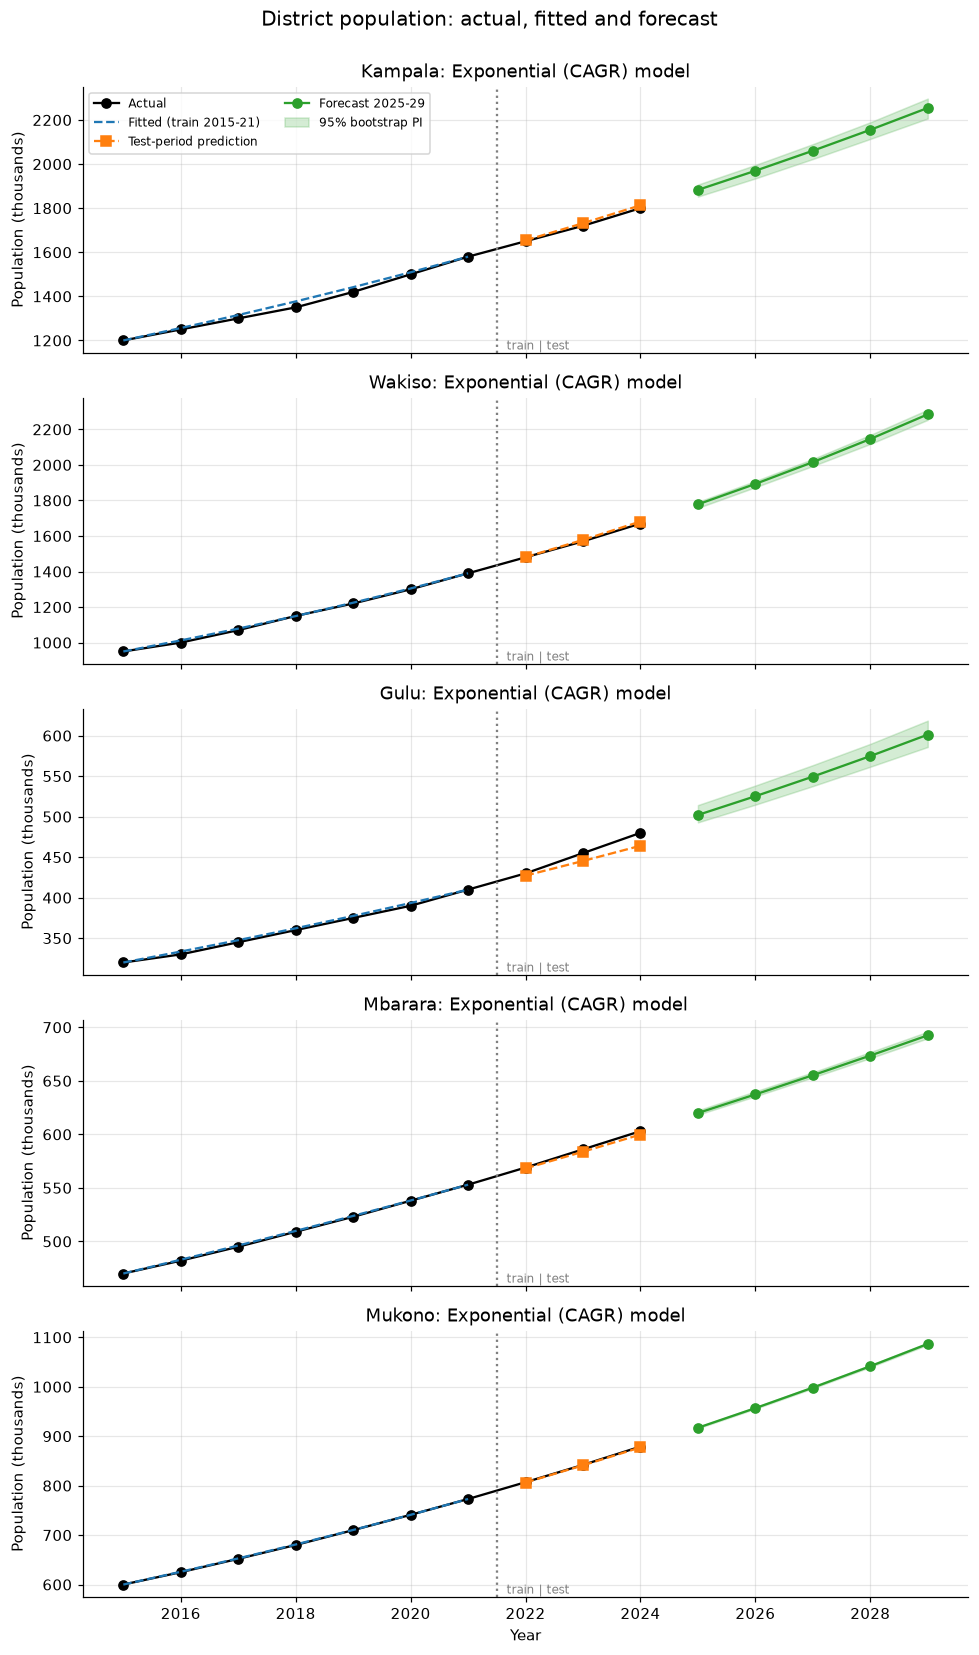

In [10]:
fig, axes = plt.subplots(len(districts), 1, figsize=(9, 3.0 * len(districts)), sharex=True)
for ax, d in zip(axes, districts):
    train, _ = d.split(2021)
    factory = MODEL_FACTORIES[best[d.name]]
    m_train = factory().fit(train.populations, train.years - train.years[0])
    ax.plot(d.years, d.populations, "o-", color="black", label="Actual")
    ax.plot(train.years, m_train.fitted(), "--", color="tab:blue", label="Fitted (train 2015-21)")
    ax.plot(np.arange(2022, 2025), m_train.predict(3), "s--", color="tab:orange",
            label="Test-period prediction")
    ax.plot(future_years, forecasts[d.name], "o-", color="tab:green", label="Forecast 2025-29")
    lo, hi = intervals[d.name]
    ax.fill_between(future_years, lo, hi, color="tab:green", alpha=0.2, label="95% bootstrap PI")
    ax.axvline(2021.5, color="grey", ls=":", lw=1.5)
    ax.text(2021.6, ax.get_ylim()[0], " train | test", va="bottom", fontsize=8, color="grey")
    ax.set_title(f"{d.name}: {best[d.name]} model")
    ax.set_ylabel("Population (thousands)")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
axes[-1].set_xlabel("Year")
fig.suptitle("District population: actual, fitted and forecast", y=1.0, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "p1_forecasts.png", bbox_inches="tight")
plt.show()

## Task 8: Classroom planning
I assume 18% of the population is of primary-school age and each classroom holds 53 pupils. The extra classrooms needed are $\lceil 0.18\,(P_{2029} - P_{2024})\times 1000 / 53 \rceil$. I round up, because a classroom can't be partly built. The upper bound of the prediction interval gives a planning range.

In [11]:
planner = ClassroomPlanner(school_age_share=0.18, pupils_per_classroom=53)
plan = pd.DataFrame({
    "pop 2024 (k)": [d.populations[-1] for d in districts],
    "pop 2029 (k)": [forecasts[d.name][-1] for d in districts],
    "extra pupils": [planner.pupils(forecasts[d.name][-1]) - planner.pupils(d.populations[-1]) for d in districts],
    "extra classrooms": [planner.additional_classrooms(d.populations[-1], forecasts[d.name][-1]) for d in districts],
    "upper PI classrooms": [planner.additional_classrooms(d.populations[-1], intervals[d.name][1][-1]) for d in districts],
}, index=[d.name for d in districts])
# Hand check, Gulu: (601.45-480)*1000*0.18/53 -> ceil
gulu_fc = forecasts["Gulu"][-1]
assert plan.loc["Gulu", "extra classrooms"] == int(np.ceil((gulu_fc - 480) * 180 / 53))
plan.round(0)

,pop 2024 (k),pop 2029 (k),extra pupils,extra classrooms,upper PI classrooms
Kampala,"1,800.00","2,255.00","81,857.00",1545,1688
Wakiso,"1,670.00","2,285.00","110,641.00",2088,2177
Gulu,480.00,601.00,"21,829.00",412,471
Mbarara,603.00,693.00,"16,116.00",305,316
Mukono,879.00,"1,087.00","37,391.00",706,714


## Extension: How defensible is the Fibonacci-ratio model?

In [12]:
ratios = FibonacciRatioForecaster().ratios(10)
print("Successive ratios:", np.round(ratios, 4))
print("Golden ratio phi =", round((1 + 5 ** 0.5) / 2, 4))
print("Cumulative multiplier after 5 years:", np.cumprod(ratios[:5]))
late = FibonacciRatioForecaster(start=15).ratios(5)
print("Even starting late in the sequence, ratios are:", np.round(late, 4))

Successive ratios: [1.     2.     1.5    1.6667 1.6    1.625  1.6154 1.619  1.6176 1.6182]
Golden ratio phi = 1.618
Cumulative multiplier after 5 years: [1. 2. 3. 5. 8.]
Even starting late in the sequence, ratios are: [1.618 1.618 1.618 1.618 1.618]


The Fibonacci ratios $F_{n+1}/F_n$ (1, 2, 1.5, 1.67, 1.6, …) quickly settle at $\varphi\approx1.618$. The model therefore implies about **62% annual growth**, and its early ratios swing between 0% and 100%. Starting later in the sequence removes the swings but not the 62% rate. Uganda's population grows at about 3% a year, and even the fastest-growing district here manages only 6.5%.

The model is defensible only if growth is *self-reinforcing* in the way Fibonacci's rabbits were: every pair breeds at once, nothing dies and nothing limits growth, so each generation adds the previous two. That might roughly describe the first years of an unconstrained biological population. It does not describe a human district, where births, deaths and migration change slowly. It also has **no parameter fitted to the data**, which is why it can't be validated and why it failed the backtest by about 80%.

## Findings & Limitations

**Findings.** All five districts grow roughly exponentially rather than in a straight line. The CAGR model beat the linear trend in every held-out test (MAPE 0.1–2%, against 1–4% for linear), and the Fibonacci model was not usable (MAPE of about 80%). Wakiso is the fastest-growing district at 6.5% a year, and it also needs the most classrooms: about **2,090 more by 2029**, compared with about 1,550 in Kampala, 710 in Mukono, 410 in Gulu and 310 in Mbarara. The bootstrap intervals are narrow because the illustrative series are very smooth. Planning to the upper 95% bound adds only 1–15% more classrooms (for example, Gulu 412 → 471), which is a cheap buffer against under-provision. For Wakiso and Kampala, that is a building programme of several hundred classrooms a year, which should shape budget requests now rather than in 2028.

**Limitations.** (1) The data is illustrative, and a 10-point series can't separate exponential from polynomial growth with much confidence. The test window covers only 3 years. (2) The CAGR model assumes the 2015–2021 growth rate continues unchanged to 2029. Urbanisation and migration policy, such as Wakiso absorbing Kampala's overflow, could break that assumption. (3) Using a flat 18% school-age share ignores changes in age structure. A declining fertility rate would lower the share and overstate the need. (4) The calculation counts only *new* pupils. It ignores the existing classroom shortfall, overcrowding, teacher supply, and whether children in private schools reduce the demand for public classrooms. (5) Residual bootstrapping assumes the errors are independent, which is unlikely for population estimates that are interpolated between censuses. Real planning should use the UBOS projections from the 2024 census and the district's age pyramid.